In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# DATA_FILE = "results2.json"
DATA_FILE = "results_vocab_tokens_00000000.json"
with open(DATA_FILE) as f:
    records = json.load(f)

nonces = np.array([r["nonce"]     for r in records], dtype=np.int64)
argmax = np.array([r["argmax_idx"] for r in records], dtype=np.int64)

vocab_size = int(argmax.max()) + 1
print(f"Loaded {len(nonces)} records  |  nonce range [{nonces.min()}, {nonces.max()}]"
      f"  |  argmax range [{argmax.min()}, {argmax.max()}]  (vocab ≈ {vocab_size:,})")

Loaded 256 records  |  nonce range [0, 255]  |  argmax range [1, 106443]  (vocab ≈ 106,444)


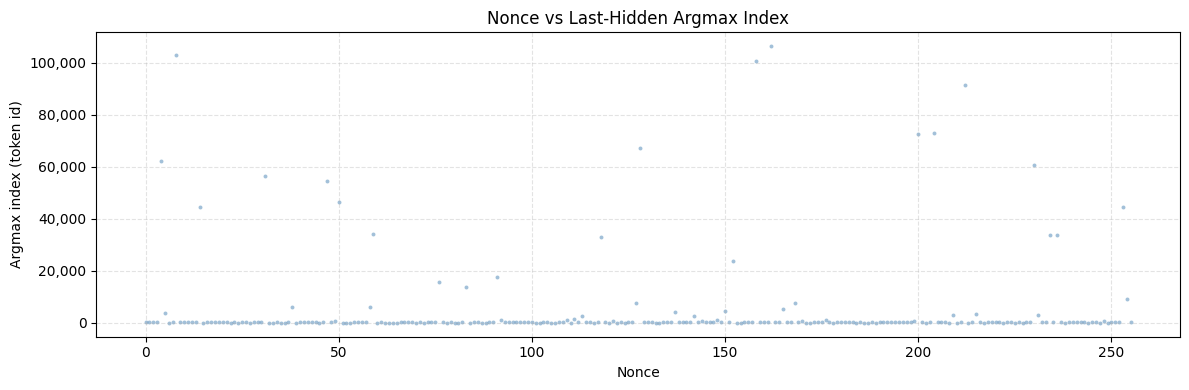

In [23]:
# ── Scatter: nonce vs argmax index ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

ax.scatter(nonces, argmax, s=8, alpha=0.5, color="steelblue", linewidths=0)
ax.set_xlabel("Nonce")
ax.set_ylabel("Argmax index (token id)")
ax.set_title("Nonce vs Last-Hidden Argmax Index")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(True, linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

In [ ]:
# ── Histogram: distribution of argmax indices ────────────────────────────────
# Set idx_min / idx_max to zoom into a sub-range of the vocabulary.
# Leave both as None to show the full range.

IDX_MIN  = None   # e.g. 0
IDX_MAX  = None   # e.g. 5000
N_BINS   = 60

# ─────────────────────────────────────────────────────────────────────────────

lo = argmax.min() if IDX_MIN is None else IDX_MIN
hi = argmax.max() if IDX_MAX is None else IDX_MAX

mask   = (argmax >= lo) & (argmax <= hi)
subset = argmax[mask]
pct    = 100 * mask.sum() / len(argmax)

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(subset, bins=N_BINS, range=(lo, hi),
        color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel("Argmax index (token id)")
ax.set_ylabel("Count")
ax.set_title(f"Argmax index distribution  [{lo:,} – {hi:,}]  "
             f"({mask.sum()} / {len(argmax)} records, {pct:.1f}%)")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(True, linestyle="--", alpha=0.35, axis="y")

plt.tight_layout()
plt.show()

print(f"Showing {mask.sum()} of {len(argmax)} records in range [{lo:,}, {hi:,}]")
print(f"Mode in range: {int(np.bincount(subset - lo).argmax()) + lo:,}"
      f"  (count = {np.bincount(subset - lo).max()})")

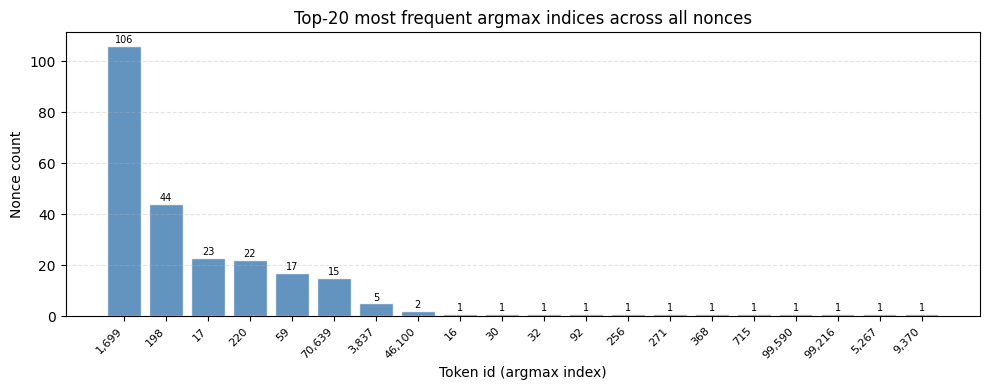

In [3]:
# ── Top-N most frequent argmax indices ───────────────────────────────────────
TOP_N = 20

unique, counts = np.unique(argmax, return_counts=True)
order  = np.argsort(counts)[::-1][:TOP_N]
top_ids, top_cnt = unique[order], counts[order]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(TOP_N), top_cnt, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xticks(range(TOP_N))
ax.set_xticklabels([f"{v:,}" for v in top_ids], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Token id (argmax index)")
ax.set_ylabel("Nonce count")
ax.set_title(f"Top-{TOP_N} most frequent argmax indices across all nonces")
ax.grid(True, linestyle="--", alpha=0.35, axis="y")

for bar, cnt in zip(bars, top_cnt):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(cnt), ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

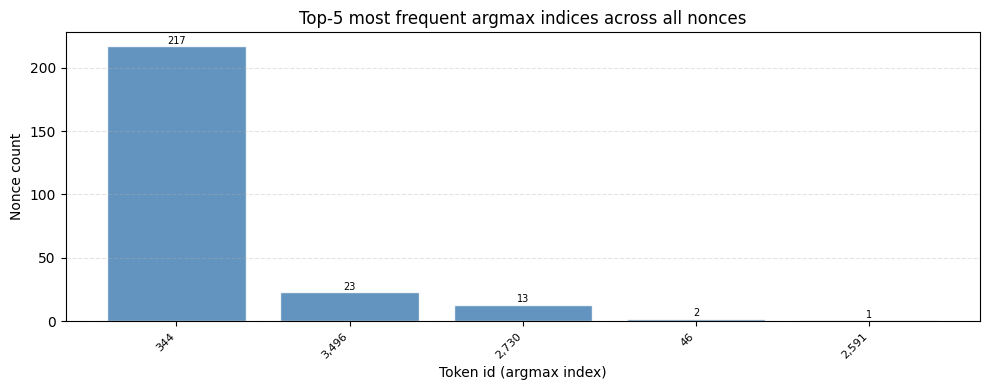

In [12]:
# ── Top-N most frequent argmax indices ───────────────────────────────────────
TOP_N = 5

unique, counts = np.unique(argmax, return_counts=True)
order  = np.argsort(counts)[::-1][:TOP_N]
top_ids, top_cnt = unique[order], counts[order]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(TOP_N), top_cnt, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xticks(range(TOP_N))
ax.set_xticklabels([f"{v:,}" for v in top_ids], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Token id (argmax index)")
ax.set_ylabel("Nonce count")
ax.set_title(f"Top-{TOP_N} most frequent argmax indices across all nonces")
ax.grid(True, linestyle="--", alpha=0.35, axis="y")

for bar, cnt in zip(bars, top_cnt):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(cnt), ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

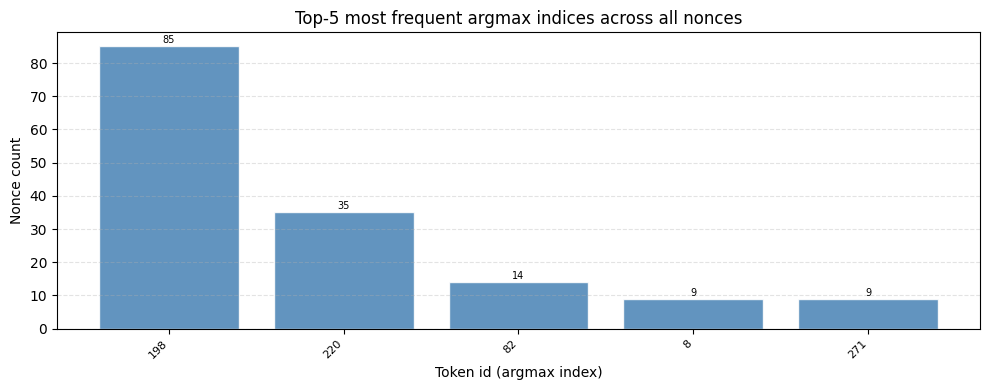

In [26]:
# ── Top-N most frequent argmax indices ───────────────────────────────────────
TOP_N = 5

unique, counts = np.unique(argmax, return_counts=True)
order  = np.argsort(counts)[::-1][:TOP_N]
top_ids, top_cnt = unique[order], counts[order]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(TOP_N), top_cnt, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xticks(range(TOP_N))
ax.set_xticklabels([f"{v:,}" for v in top_ids], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Token id (argmax index)")
ax.set_ylabel("Nonce count")
ax.set_title(f"Top-{TOP_N} most frequent argmax indices across all nonces")
ax.grid(True, linestyle="--", alpha=0.35, axis="y")

for bar, cnt in zip(bars, top_cnt):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(cnt), ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

In [2]:
import glob
import json
import numpy as np

# ── glob pattern for per-hash files ──────────────────────────────────────────
FILE_PATTERN = "results_sampled_logits_diff_hashes_*.json"
# ─────────────────────────────────────────────────────────────────────────────

hash_data = {}   # short_name -> np.ndarray of argmax indices

for path in sorted(glob.glob(FILE_PATTERN)):
    short = path.replace(".json", "").split("_")[-1]   # last 8-char hex prefix
    with open(path) as f:
        records = json.load(f)
    hash_data[short] = np.array([r["argmax_idx"] for r in records], dtype=np.int64)

print(f"Loaded {len(hash_data)} files:")
for name, arr in hash_data.items():
    print(f"  {name}  —  {len(arr)} nonces, argmax range [{arr.min()}, {arr.max()}]")

Loaded 4 files:
  176d2767  —  256 nonces, argmax range [49, 145953]
  affca3d8  —  256 nonces, argmax range [59, 145202]
  ec36ff5f  —  256 nonces, argmax range [9, 148167]
  f49f9913  —  256 nonces, argmax range [54, 144842]


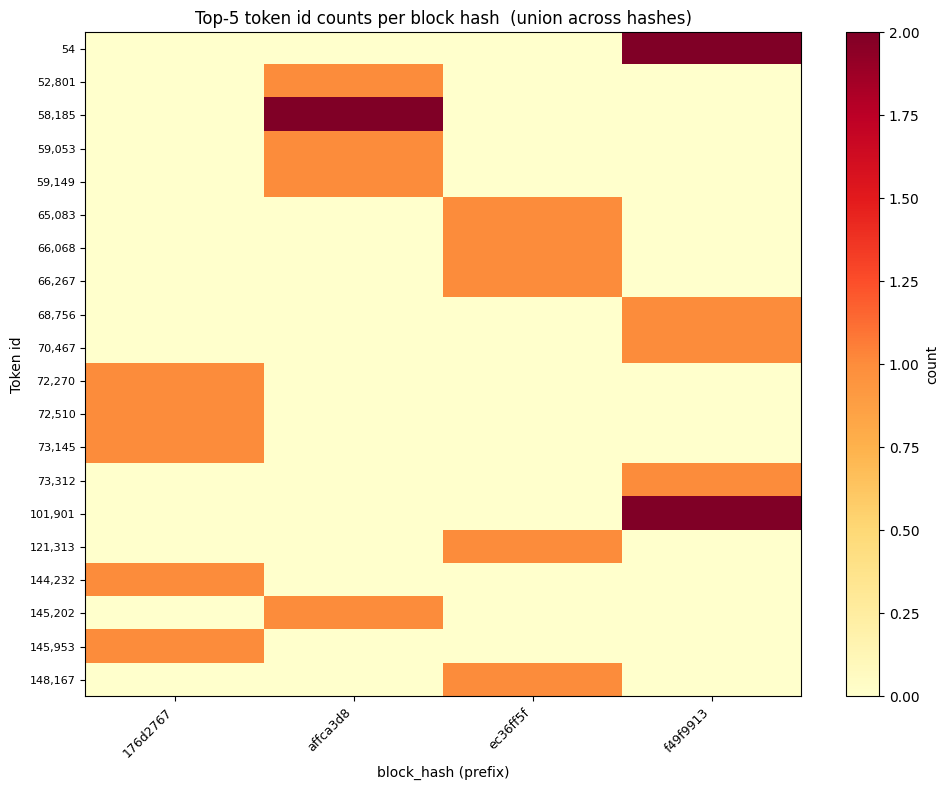

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# ── parameters ────────────────────────────────────────────────────────────────
TOP_N   = 5     # how many top token ids to track per hash
# ─────────────────────────────────────────────────────────────────────────────

COLORS = [
    "steelblue", "tomato", "seagreen", "darkorange",
    "mediumpurple", "hotpink", "saddlebrown", "teal",
    "olive", "crimson", "dodgerblue", "coral",
]

names  = list(hash_data.keys())
n_hash = len(names)

# ── per-hash top-N token ids and their counts ─────────────────────────────────
top_tables = {}
for name, arr in hash_data.items():
    unique, counts = np.unique(arr, return_counts=True)
    order = np.argsort(counts)[::-1][:TOP_N]
    top_tables[name] = dict(zip(unique[order].tolist(), counts[order].tolist()))

# ── union of all token ids that appear in any top-N ──────────────────────────
all_top_ids = sorted({tid for tbl in top_tables.values() for tid in tbl})

# build a DataFrame: rows = token ids, columns = hash names
df = pd.DataFrame(
    {name: [top_tables[name].get(tid, 0) for tid in all_top_ids] for name in names},
    index=all_top_ids,
)
df.index.name = "token_id"

# ── 1. Heatmap: count per (token_id, hash) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(10, n_hash * 1.1), max(6, len(all_top_ids) * 0.4)))

im = ax.imshow(df.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(n_hash))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(all_top_ids)))
ax.set_yticklabels([f"{t:,}" for t in all_top_ids], fontsize=8)
ax.set_xlabel("block_hash (prefix)")
ax.set_ylabel("Token id")
ax.set_title(f"Top-{TOP_N} token id counts per block hash  (union across hashes)")
plt.colorbar(im, ax=ax, label="count")
plt.tight_layout()
plt.show()

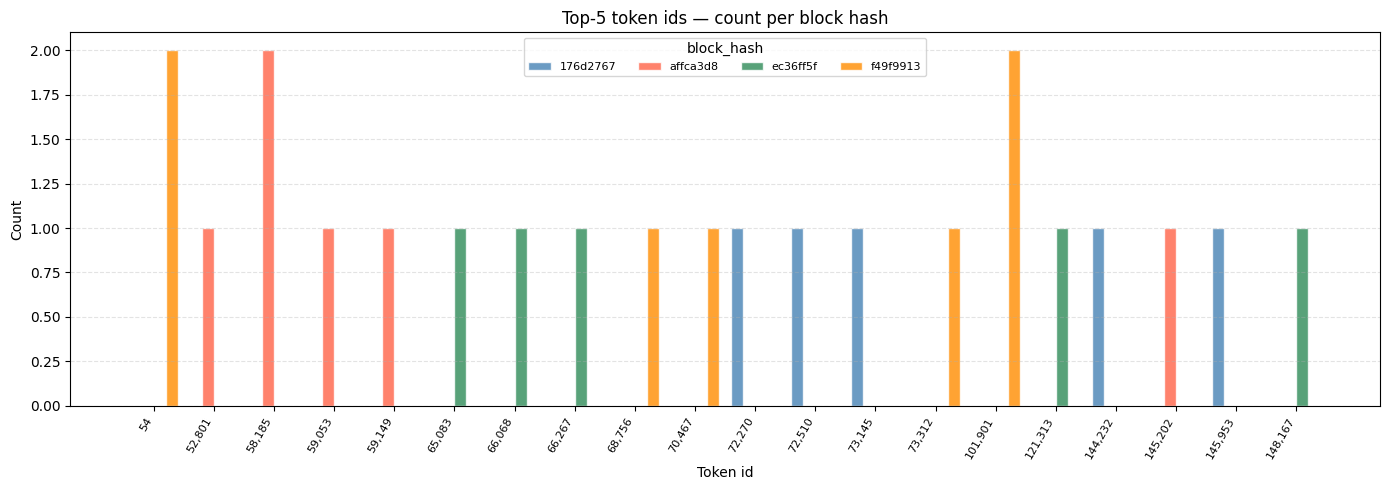

In [7]:
# ── 2. Grouped bar: each hash as a group, bars = top token ids ────────────────
# Show only token ids that appear in at least one hash's top-N
x = np.arange(len(all_top_ids))
bar_w = 0.8 / max(n_hash, 1)

fig2, ax2 = plt.subplots(figsize=(max(14, len(all_top_ids) * 0.7), 5))
for i, name in enumerate(names):
    counts = df[name].values
    offset = (i - n_hash / 2 + 0.5) * bar_w
    ax2.bar(x + offset, counts, bar_w, label=name,
            color=COLORS[i % len(COLORS)], alpha=0.8, edgecolor="white")

ax2.set_xticks(x)
ax2.set_xticklabels([f"{t:,}" for t in all_top_ids], rotation=60, ha="right", fontsize=8)
ax2.set_xlabel("Token id")
ax2.set_ylabel("Count")
ax2.set_title(f"Top-{TOP_N} token ids — count per block hash")
ax2.legend(title="block_hash", fontsize=8, ncol=min(n_hash, 5))
ax2.grid(True, linestyle="--", alpha=0.35, axis="y")
plt.tight_layout()
plt.show()

In [ ]:
import torch
k = 4

W = torch.randn(1, k) 

tensor([29397])

In [2]:
values = torch.tensor([0.82031, 0.71094, 3.25000, 4.31250])
scalar = torch.sigmoid(W @ values)   # ∈ (0, 1)
result_index = (scalar * 32000).long()
result_index

tensor([29397])

In [3]:
values = torch.tensor([0.71094, 0.82031, 3.25000, 4.31250])
scalar = torch.sigmoid(W @ values)   # ∈ (0, 1)
result_index = (scalar * 32000).long()
result_index

tensor([29260])

In [ ]:
values = torch.tensor([0.72094, 0.82031, 3.25000, 4.31250])
scalar = torch.sigmoid(W @ values)   # ∈ (0, 1)
result_index = (scalar * 32000).long()
result_index

tensor([29258])

In [ ]:
def xy_to_hilbert(x, y, order):
    """
    (x, y) ∈ [0, 2^order) → hilbert index
    order определяет точность сетки
    """
    n = 2 ** order
    d = 0
    s = n // 2
    while s > 0:
        rx = 1 if (x & s) > 0 else 0
        ry = 1 if (y & s) > 0 else 0
        d += s * s * ((3 * rx) ^ ry)
        # поворот квадранта
        if ry == 0:
            if rx == 1:
                x = s - 1 - x
                y = s - 1 - y
            x, y = y, x
        s //= 2
    return d


order = 8        # сетка 256×256 = 65536 ячеек > 32000 ✓
n = 2 ** order   # = 256

values = torch.tensor([0.72094, 0.82031, 3.25000, 4.31250])
v_norm = values / values.norm()   # проекция на сферу S^(k-1)

# берём первые 2 компоненты, маппируем из [-1, 1] → [0, 255]
xi = int((v_norm[0].item() + 1) / 2 * (n - 1))
yi = int((v_norm[1].item() + 1) / 2 * (n - 1))

hilbert_idx = xy_to_hilbert(xi, yi, order)
result_index = hilbert_idx % 32000
result_index

1275

In [ ]:
base = torch.tensor(2.0)
powers = base ** torch.arange(k).float()


# Значения → коэффициенты многочлена p(base)
values = torch.tensor([0.72094, 0.82031, 3.25000, 4.31250])
poly_val = (values * powers).sum()
result_index = poly_val.abs().long() % 32000
result_index

tensor(49)

In [ ]:
values = torch.tensor([0.73094, 0.82031, 3.25000, 4.31250])
log_sum = torch.log(values.abs() + 1e-8).median()
geo_mean = torch.exp(log_sum)

# нормализуем в диапазон [0, 32000]
result_index = (torch.sigmoid(geo_mean) * 32000).long()
result_index

tensor(22289)